# 광고 어뷰징 탐지 정리

적립·참여 로그 기준 이상 클릭, CTIT, IP 집중 패턴 확인
확정 어뷰징 제거본과 대시보드 CSV 생성


## 1. 기본 설정

라이브러리, 판정 라벨만 먼저 정리


In [1]:
import warnings
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


normal_label = '정상'
extreme_label = '어뷰징 확정'
suspect_label = '의심'
unrewarded_label = '미적립'



C:\Users\ckcma\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 2. 원본 로드

광고 목록·적립 로그·참여 로그·시간대 리포트 사용
필요 컬럼만 읽어서 시작


In [2]:
# 광고 목록
df_master = pd.read_csv(
    'C:/Users/ckcma/Downloads/temp2/IVE_광고목록.csv',
    usecols=['ads_idx', 'ads_type'],
    encoding='utf-8-sig'
)

df_master.shape


(445260, 2)

In [3]:
# 적립 로그
df_reward = pd.read_csv(
    'C:/Users/ckcma/Downloads/temp2/IVE_광고적립_all.csv',
    usecols=[
        'ads_idx', 'mda_idx', 'advid', 'click_key', 'show_cost', 'adv_cost',
        'rwd_cost', 'earn_cost', 'click_date', 'ctit',
    ],
    encoding='utf-8-sig'
)

df_reward.shape


(1475031, 10)

In [4]:
# 참여 로그
df_engagement = pd.read_csv(
    'C:/Users/ckcma/Downloads/temp2/IVE_광고참여정보.csv',
    usecols=[
        'click_key', 'dvc_idx', 'mda_idx', 'click_date', 'user_ip',
        'network', 'carrier', 'adv_price', 'contract_price', 'media_price', 'reward_price',
    ],
    encoding='utf-8-sig'
)

df_engagement.shape


(16854865, 11)

In [5]:
# 시간대 리포트
df_report = pd.read_csv(
    'C:/Users/ckcma/Downloads/temp2/260322_0700_중간과정/아이브시간대별광고리포트_1년치_all.csv',
    usecols=['rpt_time_date', 'ads_idx', 'mda_idx', 'rpt_time_clk', 'rpt_time_turn', 'rpt_time_earn'],
    encoding='utf-8-sig'
)

df_report.shape


(6953146, 6)

In [6]:
# 키 타입
df_reward['click_key'] = df_reward['click_key'].astype('object')
df_engagement['click_key'] = df_engagement['click_key'].astype('object')
df_reward['mda_idx'] = df_reward['mda_idx'].astype('object')
df_engagement['mda_idx'] = df_engagement['mda_idx'].astype('object')


## 3. 전처리

비용 역전, 목록 미매칭, click_key 불일치 제거
위험 판정용 로그만 남김


In [7]:
# 참여 로그 확인
rows_before_click = len(df_engagement)

missing_count = df_engagement[['network', 'carrier']].isna().sum().sum()
price_error_count = (
    (pd.to_numeric(df_engagement['adv_price'], errors='coerce') < pd.to_numeric(df_engagement['contract_price'], errors='coerce')) |
    (pd.to_numeric(df_engagement['contract_price'], errors='coerce') < pd.to_numeric(df_engagement['media_price'], errors='coerce')) |
    (pd.to_numeric(df_engagement['media_price'], errors='coerce') < pd.to_numeric(df_engagement['reward_price'], errors='coerce'))
).sum()

pd.Series({
    '참여 로그 행': rows_before_click,
    'network/carrier 결측': missing_count,
    '비용 오류 후보': price_error_count,
})


참여 로그 행               16854865
network/carrier 결측    18644283
비용 오류 후보                 23802
dtype: int64

In [8]:
# 적립 로그 확인
rows_before_reward = len(df_reward)

reward_missing = df_reward['advid'].isna().sum()
reward_price_error = (
    (pd.to_numeric(df_reward['show_cost'], errors='coerce') < pd.to_numeric(df_reward['adv_cost'], errors='coerce')) |
    (pd.to_numeric(df_reward['adv_cost'], errors='coerce') < pd.to_numeric(df_reward['earn_cost'], errors='coerce')) |
    (pd.to_numeric(df_reward['earn_cost'], errors='coerce') < pd.to_numeric(df_reward['rwd_cost'], errors='coerce'))
).sum()

pd.Series({
    '적립 로그 행': rows_before_reward,
    'advid 결측': reward_missing,
    '비용 오류 후보': reward_price_error,
})


적립 로그 행     1475031
advid 결측       7171
비용 오류 후보       4417
dtype: int64

In [9]:
# 참여 로그
df_engagement['network'] = df_engagement['network'].fillna('Unknown').replace('', 'Unknown')
if 'carrier' in df_engagement.columns:
    df_engagement = df_engagement.drop(columns=['carrier'])

# 참여 비용
price_cols = ['adv_price', 'contract_price', 'media_price', 'reward_price']
for col in price_cols:
    df_engagement[col] = pd.to_numeric(df_engagement[col], errors='coerce').fillna(0)

# 참여 비용 오류 제거
price_error = ~(
    (df_engagement['adv_price'] >= df_engagement['contract_price']) &
    (df_engagement['contract_price'] >= df_engagement['media_price']) &
    (df_engagement['media_price'] >= df_engagement['reward_price'])
)
df_engagement = df_engagement[~price_error].copy()

df_engagement.shape


(16831063, 10)

In [10]:
# 적립 로그
df_reward['advid'] = df_reward['advid'].fillna('Unknown').replace('', 'Unknown')
for col in ['show_cost', 'adv_cost', 'rwd_cost', 'earn_cost', 'ctit']:
    df_reward[col] = pd.to_numeric(df_reward[col], errors='coerce').fillna(0)
df_reward['click_date'] = pd.to_datetime(df_reward['click_date'], errors='coerce').dt.date

# 적립 비용 오류 제거
reward_price_error = ~(
    (df_reward['show_cost'] >= df_reward['adv_cost']) &
    (df_reward['adv_cost'] >= df_reward['earn_cost']) &
    (df_reward['earn_cost'] >= df_reward['rwd_cost'])
)
df_reward = df_reward[~reward_price_error].copy()
after_reward_price = len(df_reward)

df_reward.shape


(1470614, 10)

In [11]:
# 광고 목록 매칭
df_reward = df_reward[df_reward['ads_idx'].isin(df_master['ads_idx'])].copy()
after_master = len(df_reward)

# click_key 매칭
click_ip = df_engagement[['click_key', 'user_ip']].drop_duplicates('click_key')
df_reward = df_reward.merge(click_ip, on='click_key', how='inner')
after_key = len(df_reward)

# IP 결측
missing_ip = df_reward['user_ip'].isna().sum()
df_reward = df_reward[df_reward['user_ip'].notna()].copy()
df_reward = df_reward.drop(columns=['user_ip'])

# 판정용 로그
score_base = df_engagement[df_engagement['click_key'].isin(df_reward['click_key'])].copy()

# 전처리 확인
pd.Series({
    '참여 carrier 제거': 1,
    '참여 비용 오류 제거': rows_before_click - len(df_engagement),
    '적립 비용 오류 제거': rows_before_reward - after_reward_price,
    '광고목록 제외': after_reward_price - after_master,
    'click_key 제외': after_master - after_key,
    'IP 결측 제외': missing_ip,
    '적립 로그': df_reward.shape,
    '판정용 로그': score_base.shape,
})


참여 carrier 제거                1
참여 비용 오류 제거              23802
적립 비용 오류 제거               4417
광고목록 제외                      0
click_key 제외                81
IP 결측 제외                     0
적립 로그            (1470533, 10)
판정용 로그           (1470533, 10)
dtype: object

## 4. 위험 판정

CTIT, IP 다기기, IP 클릭 집중 기준 확인
중간 셀은 판정용 테이블 생성, 최종 분포는 아래 판정 분포에서 확인


In [12]:
# CTIT
df_reward = df_reward.merge(df_master[['ads_idx', 'ads_type']], on='ads_idx', how='left')

# 유형별 기준
ctit_cut = (
    df_reward[df_reward['ads_type'] != 4]
    .groupby('ads_type')['ctit']
    .median()
    .mul(0.1)
    .rename('ctit_cut')
)
df_reward = df_reward.merge(ctit_cut, on='ads_type', how='left')

# CTIT 이상
df_reward['ctit_error'] = (
    ((df_reward['ads_type'] == 4) & (df_reward['ctit'] == 0)) |
    ((df_reward['ads_type'] != 4) & (df_reward['ctit'] < df_reward['ctit_cut']))
)
df_reward['ctit_label'] = np.where(df_reward['ctit_error'], suspect_label, normal_label)


In [13]:
# IP 집중
ip = score_base.groupby(['mda_idx', 'user_ip'], as_index=False).agg(
    device_count=('dvc_idx', 'nunique'),
    click_count=('click_key', 'count'),
)
# 0.1% 컷
device_cut = ip['device_count'].quantile(0.999)
click_cut = ip['click_count'].quantile(0.999)

# 집중 플래그
ip['is_device_error'] = ip['device_count'] > device_cut
ip['is_click_error'] = ip['click_count'] > click_cut
ip['device_label'] = np.where(ip['is_device_error'], suspect_label, normal_label)
ip['click_label'] = np.where(ip['is_click_error'], suspect_label, normal_label)


In [14]:
# 판정 테이블
click_base = score_base[['click_key', 'user_ip', 'dvc_idx']].drop_duplicates('click_key')
base_cols = [
    'ads_idx', 'mda_idx', 'click_key', 'show_cost', 'adv_cost', 'rwd_cost', 'earn_cost',
    'click_date', 'ctit', 'ctit_error', 'ctit_label',
]
base = df_reward[base_cols].merge(click_base, on='click_key', how='inner')
base = base.merge(ip, on=['mda_idx', 'user_ip'], how='left')

# row_label
base['is_rewarded'] = base['rwd_cost'] > 0
has_error = base['ctit_error'] | base['is_device_error'].fillna(False) | base['is_click_error'].fillna(False)
base['row_label'] = np.where(~base['is_rewarded'], unrewarded_label, np.where(has_error, extreme_label, normal_label))
base['fraud_loss'] = np.where((base['is_rewarded']) & (base['row_label'] == extreme_label), base['earn_cost'], 0)
base['row_score'] = base['row_label'].map({normal_label: 100, suspect_label: 40, extreme_label: 10, unrewarded_label: 0}).fillna(100)

# df_base
df_base = base
del score_base, click_base, ip
_ = gc.collect()


In [15]:
# 판정 분포
label = df_base['row_label'].value_counts().reset_index()
label.columns = ['판정', '행수']
label['비율(%)'] = (label['행수'] / label['행수'].sum() * 100).round(2)
display(label)


,판정,행수,비율(%)
0,정상,929790,63.2300
1,어뷰징 확정,540743,36.7700


## 4-1. 도메인 오염도

도메인 라벨 붙여서 유형·도메인별 손실 확인


In [16]:
# 도메인 라벨
# 라벨 매핑
domain_map = {1: '엔터', 2: '금융', 3: '라이프', 4: '커머스', 5: '기타'}
type_map = {
    1: '설치형', 2: '실행형', 3: '참여형', 4: '클릭형',
    5: '페이스북', 6: '트위터', 7: '인스타그램',
    9: '퀘스트', 10: '유튜브', 11: '네이버', 12: 'CPS(구매)'
}

# 라벨 CSV
ad_meta = pd.read_csv(
    'C:/Users/ckcma/Downloads/temp2/04 ADS/IVE_광고목록_도메인라벨링_수기보정.csv',
    usecols=['ads_idx', 'ads_type', 'domain_label'],
    encoding='utf-8-sig',
)
ad_meta['type_name'] = ad_meta['ads_type'].map(type_map).fillna('기타')
ad_meta['domain_name'] = ad_meta['domain_label'].map(domain_map).fillna('기타')

# 라벨 결합
abuse_view = df_base.merge(
    ad_meta[['ads_idx', 'ads_type', 'type_name', 'domain_label', 'domain_name']],
    on='ads_idx',
    how='left',
)

# 플래그 타입
for col in ['ctit_error', 'is_device_error', 'is_click_error']:
    abuse_view[col] = abuse_view[col].fillna(False).astype(bool)

# 전체 기준
total_loss = abuse_view['fraud_loss'].sum()
total_extreme = (abuse_view['row_label'] == extreme_label).sum()


In [17]:
# 유형별 오염도
type_sum = abuse_view.groupby('type_name', dropna=False).agg(
    전체건수=('click_key', 'count'),
    어뷰징확정건수=('row_label', lambda x: (x == extreme_label).sum()),
    극단값손실액=('fraud_loss', 'sum'),
    CTIT이상건수=('ctit_error', 'sum'),
    동일IP다기기건수=('is_device_error', 'sum'),
    IP클릭집중건수=('is_click_error', 'sum'),
).reset_index().rename(columns={'type_name': '광고유형'})

# 비율
type_sum['오염도비율(%)'] = type_sum['어뷰징확정건수'] / type_sum['전체건수'] * 100
type_sum['어뷰징확정점유율(%)'] = type_sum['어뷰징확정건수'] / total_extreme * 100
type_sum['손실액점유율(%)'] = type_sum['극단값손실액'] / total_loss * 100
type_sum['CTIT이상비율(%)'] = type_sum['CTIT이상건수'] / type_sum['전체건수'] * 100
type_sum['동일IP다기기비율(%)'] = type_sum['동일IP다기기건수'] / type_sum['전체건수'] * 100
type_sum['IP클릭집중비율(%)'] = type_sum['IP클릭집중건수'] / type_sum['전체건수'] * 100

# 반올림
for col in ['오염도비율(%)', '어뷰징확정점유율(%)', '손실액점유율(%)', 'CTIT이상비율(%)', '동일IP다기기비율(%)', 'IP클릭집중비율(%)']:
    type_sum[col] = type_sum[col].round(2)

type_sum['극단값손실액'] = type_sum['극단값손실액'].round(0).astype('int64')
type_sum = type_sum.sort_values(['손실액점유율(%)', '어뷰징확정점유율(%)'], ascending=False)

display(type_sum)


,광고유형,전체건수,어뷰징확정건수,극단값손실액,CTIT이상건수,동일IP다기기건수,IP클릭집중건수,오염도비율(%),어뷰징확정점유율(%),손실액점유율(%),CTIT이상비율(%),동일IP다기기비율(%),IP클릭집중비율(%)
2,설치형,585504,199236,31403749,30907,191217,189004,34.0300,36.8400,55.3700,5.2800,32.6600,32.2800
3,실행형,522880,68576,15867390,26436,43386,40940,13.1200,12.6800,27.9800,5.0600,8.3000,7.8300
6,참여형,316837,269741,7084431,7527,256209,269199,85.1400,49.8800,12.4900,2.3800,80.8600,84.9600
0,CPS(구매),6151,953,2257020,58,0,906,15.4900,0.1800,3.9800,0.9400,0.0000,14.7300
5,인스타그램,12262,274,47643,0,260,274,2.2300,0.0500,0.0800,0.0000,2.1200,2.2300
4,유튜브,1027,209,33440,0,209,209,20.3500,0.0400,0.0600,0.0000,20.3500,20.3500
7,클릭형,5260,1690,10492,1569,5,145,32.1300,0.3100,0.0200,29.8300,0.1000,2.7600
8,페이스북,1259,58,10386,51,6,7,4.6100,0.0100,0.0200,4.0500,0.4800,0.5600
1,네이버,19353,6,912,4,2,2,0.0300,0.0000,0.0000,0.0200,0.0100,0.0100


In [18]:
# 도메인별 오염도
domain_sum = abuse_view.groupby('domain_name', dropna=False).agg(
    전체건수=('click_key', 'count'),
    어뷰징확정건수=('row_label', lambda x: (x == extreme_label).sum()),
    극단값손실액=('fraud_loss', 'sum'),
    CTIT이상건수=('ctit_error', 'sum'),
    동일IP다기기건수=('is_device_error', 'sum'),
    IP클릭집중건수=('is_click_error', 'sum'),
).reset_index().rename(columns={'domain_name': '광고도메인'})

# 비율
domain_sum['오염도비율(%)'] = domain_sum['어뷰징확정건수'] / domain_sum['전체건수'] * 100
domain_sum['어뷰징확정점유율(%)'] = domain_sum['어뷰징확정건수'] / total_extreme * 100
domain_sum['손실액점유율(%)'] = domain_sum['극단값손실액'] / total_loss * 100
domain_sum['CTIT이상비율(%)'] = domain_sum['CTIT이상건수'] / domain_sum['전체건수'] * 100
domain_sum['동일IP다기기비율(%)'] = domain_sum['동일IP다기기건수'] / domain_sum['전체건수'] * 100
domain_sum['IP클릭집중비율(%)'] = domain_sum['IP클릭집중건수'] / domain_sum['전체건수'] * 100

# 반올림
for col in ['오염도비율(%)', '어뷰징확정점유율(%)', '손실액점유율(%)', 'CTIT이상비율(%)', '동일IP다기기비율(%)', 'IP클릭집중비율(%)']:
    domain_sum[col] = domain_sum[col].round(2)

domain_sum['극단값손실액'] = domain_sum['극단값손실액'].round(0).astype('int64')
domain_sum = domain_sum.sort_values(['손실액점유율(%)', '어뷰징확정점유율(%)'], ascending=False)

display(domain_sum)


,광고도메인,전체건수,어뷰징확정건수,극단값손실액,CTIT이상건수,동일IP다기기건수,IP클릭집중건수,오염도비율(%),어뷰징확정점유율(%),손실액점유율(%),CTIT이상비율(%),동일IP다기기비율(%),IP클릭집중비율(%)
3,엔터,1060458,271331,48804911,54024,239490,237018,25.5900,50.1800,86.0500,5.0900,22.5800,22.3500
2,라이프,202256,150197,3321447,4863,146775,149584,74.2600,27.7800,5.8600,2.4000,72.5700,73.9600
4,커머스,109389,79233,2200804,3938,70494,77160,72.4300,14.6500,3.8800,3.6000,64.4400,70.5400
0,금융,53461,4949,1743248,2888,1898,2079,9.2600,0.9200,3.0700,5.4000,3.5500,3.8900
1,기타,44969,35033,645053,839,32637,34845,77.9000,6.4800,1.1400,1.8700,72.5800,77.4900


In [19]:
# 최다 손실
top_type = type_sum.iloc[0]
top_domain = domain_sum.iloc[0]
pd.Series({
    '손실액 최다 광고유형': top_type['광고유형'],
    '광고유형 손실액점유율(%)': top_type['손실액점유율(%)'],
    '손실액 최다 광고도메인': top_domain['광고도메인'],
    '광고도메인 손실액점유율(%)': top_domain['손실액점유율(%)'],
})


손실액 최다 광고유형           설치형
광고유형 손실액점유율(%)    55.3700
손실액 최다 광고도메인           엔터
광고도메인 손실액점유율(%)   86.0500
dtype: object

## 5. 8월 이상신호

월별 클릭 수와 CVR 비교
8월 클릭 급증 구간 확인


8월 이상신호 요약

- 클릭 수 16,895,276건
- 전환 수 1,534,485건
- CVR 9.08%
- 전월 대비 클릭 증가율 +382.6%
- 전월 대비 CVR 하락폭 -36.12pp


In [20]:
df_report = df_report.copy()

# 리포트 숫자화
for col in ['rpt_time_clk', 'rpt_time_turn', 'rpt_time_earn']:
    df_report[col] = pd.to_numeric(df_report[col], errors='coerce').fillna(0)

# 월 컬럼
df_report['date'] = pd.to_datetime(df_report['rpt_time_date'], errors='coerce')
df_report['month'] = df_report['date'].dt.to_period('M').astype(str)

# 월별 집계
mon = (
    df_report.dropna(subset=['date'])
    .groupby('month', as_index=False)
    .agg(
        click=('rpt_time_clk', 'sum'),
        conv=('rpt_time_turn', 'sum'),
        earn=('rpt_time_earn', 'sum'),
    )
    .sort_values('month')
    .reset_index(drop=True)
)

mon['cvr'] = np.where(mon['click'] > 0, mon['conv'] / mon['click'] * 100, 0)
mon['click_rate'] = mon['click'].pct_change() * 100
mon['cvr_gap'] = mon['cvr'].diff()

target_month = '2025-08'
now = mon.loc[mon['month'].eq(target_month)].iloc[0]


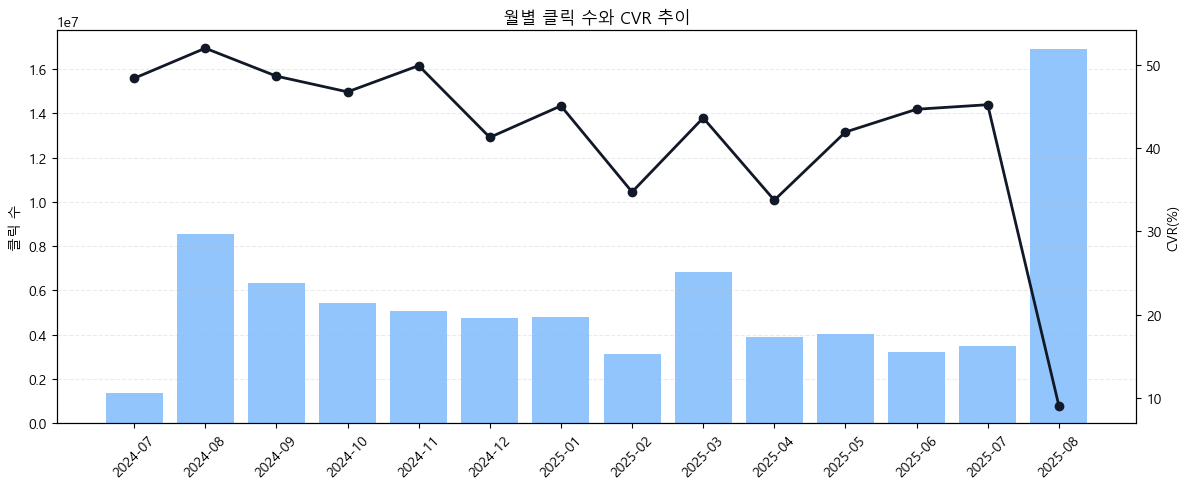

In [21]:
# 클릭/CVR 그래프
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(mon['month'], mon['click'], color='#93c5fd')
ax1.set_ylabel('클릭 수')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(mon['month'], mon['cvr'], color='#111827', marker='o', linewidth=2)
ax2.set_ylabel('CVR(%)')

ax1.set_title('월별 클릭 수와 CVR 추이')
ax1.grid(axis='y', linestyle='--', alpha=0.25)
fig.tight_layout()
plt.show()


In [22]:
# 8월 요약
avg_base = mon[mon['month'] != target_month]
avg_click = avg_base['click'].mean()
avg_conv = avg_base['conv'].mean()
avg_cvr = avg_base['conv'].sum() / avg_base['click'].sum() * 100 if avg_base['click'].sum() > 0 else 0

jul = mon.loc[mon['month'].eq('2025-07')].iloc[0]
aug = mon.loc[mon['month'].eq(target_month)].iloc[0]

pd.Series({
    '평균 클릭(8월 제외)': round(avg_click, 0),
    '평균 전환(8월 제외)': round(avg_conv, 0),
    '평균 CVR(8월 제외)': round(avg_cvr, 2),
    '7월 클릭': round(jul['click'], 0),
    '7월 전환': round(jul['conv'], 0),
    '7월 CVR': round(jul['cvr'], 2),
    '8월 클릭': round(aug['click'], 0),
    '8월 전환': round(aug['conv'], 0),
    '8월 CVR': round(aug['cvr'], 2),
})

mon_summary = mon


클릭 증가 원인

- 2025-07 클릭 수 3,500,554건
- 2025-08 클릭 수 16,895,276건
- 클릭 순증가분 13,394,722건
- 증가 매체 클릭 증가분 합계 14,429,974건
- 최대 증가 매체 mda_539, 기여율 93.1%


In [23]:
# 비교 월
month_list = mon_summary['month'].tolist()
target_idx = month_list.index(target_month)
prev_month = month_list[target_idx - 1]

# mda 표시
def fmt_mda(x):
    text = str(x).strip()
    return text[:-2] if text.endswith('.0') else text

# 매체 월 비교
target = df_report[df_report['month'].isin([prev_month, target_month])].copy()
media_month = target.groupby(['month', 'mda_idx'], as_index=False).agg(
    click=('rpt_time_clk', 'sum'),
    conv=('rpt_time_turn', 'sum'),
)
media_month['cvr'] = np.where(media_month['click'] > 0, media_month['conv'] / media_month['click'] * 100, 0)

# 전월/8월
prev = media_month[media_month['month'] == prev_month][['mda_idx', 'click', 'conv', 'cvr']]
now = media_month[media_month['month'] == target_month][['mda_idx', 'click', 'conv', 'cvr']]

# 클릭 증가분
comp = now.merge(prev, on='mda_idx', how='outer', suffixes=('_now', '_prev')).fillna(0)
comp['click_diff'] = comp['click_now'] - comp['click_prev']
comp['cvr_diff'] = comp['cvr_now'] - comp['cvr_prev']

# 기여율
total_prev = comp['click_prev'].sum()
total_now = comp['click_now'].sum()
total_diff = total_now - total_prev
positive_diff = comp.loc[comp['click_diff'] > 0, 'click_diff'].sum()
comp['diff_share'] = np.where(positive_diff > 0, comp['click_diff'] / positive_diff * 100, 0)

# Top 5
top5 = comp.sort_values('click_diff', ascending=False).head(5).reset_index(drop=True)
top5.insert(0, '순위', np.arange(1, len(top5) + 1))
top5['mda'] = 'mda_' + top5['mda_idx'].map(fmt_mda)
august_top5 = top5.rename(columns={'click_now': 'click', 'conv_now': 'conv'})


# 클릭 표
click_view = top5.rename(columns={
    'mda': '매체',
    'click_prev': f'{prev_month} 클릭 수',
    'click_now': f'{target_month} 클릭 수',
    'click_diff': '클릭 증가분',
    'diff_share': '증가 기여율(%)',
})
click_view = click_view[['순위', '매체', f'{prev_month} 클릭 수', f'{target_month} 클릭 수', '클릭 증가분', '증가 기여율(%)']]

display(click_view)


,순위,매체,2025-07 클릭 수,2025-08 클릭 수,클릭 증가분,증가 기여율(%)
0,1,mda_539,"37,439.0000","13,470,602.0000","13,433,163.0000",93.0921
1,2,mda_58,"254,067.0000","541,254.0000","287,187.0000",1.9902
2,3,mda_342,"160,617.0000","363,272.0000","202,655.0000",1.4044
3,4,mda_396,"84,549.0000","186,572.0000","102,023.0000",0.7070
4,5,mda_343,"94,590.0000","196,344.0000","101,754.0000",0.7052


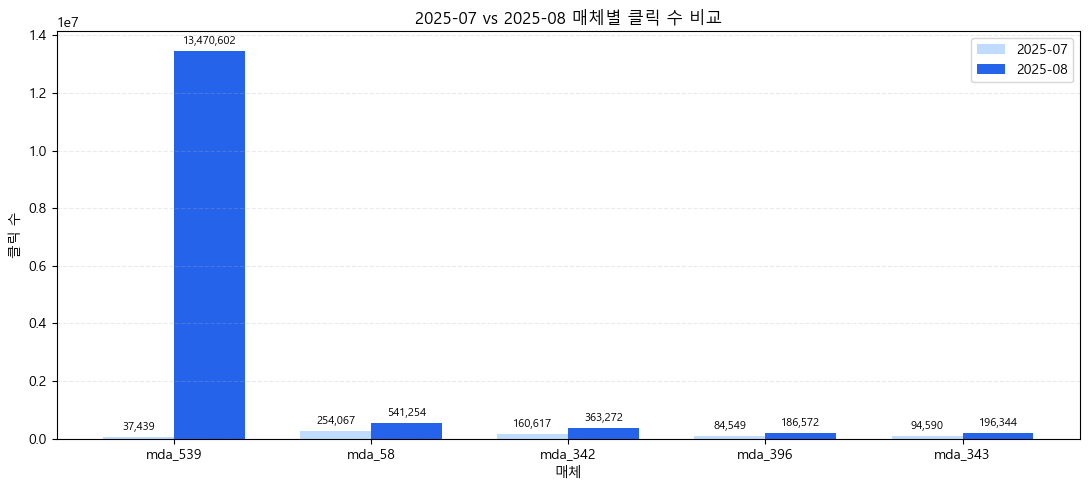

In [24]:
# 클릭 그래프
chart = top5.sort_values('순위').copy()
x = np.arange(len(chart))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5))
bars_prev = ax.bar(x - width / 2, chart['click_prev'], width, label=prev_month, color='#bfdbfe')
bars_now = ax.bar(x + width / 2, chart['click_now'], width, label=target_month, color='#2563eb')
ax.set_title(f'{prev_month} vs {target_month} 매체별 클릭 수 비교')
ax.set_xlabel('매체')
ax.set_ylabel('클릭 수')
ax.set_xticks(x)
ax.set_xticklabels(chart['mda'])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.bar_label(bars_prev, labels=[f'{v:,.0f}' for v in chart['click_prev']], padding=3, fontsize=8)
ax.bar_label(bars_now, labels=[f'{v:,.0f}' for v in chart['click_now']], padding=3, fontsize=8)
fig.tight_layout()
plt.show()


In [25]:
# CVR 비교
# CVR 표
cvr_view = top5.rename(columns={
    'mda': '매체',
    'cvr_prev': f'{prev_month} CVR(%)',
    'cvr_now': f'{target_month} CVR(%)',
    'cvr_diff': 'CVR 변화(pp)',
})
cvr_view = cvr_view[['순위', '매체', f'{prev_month} CVR(%)', f'{target_month} CVR(%)', 'CVR 변화(pp)']]

display(cvr_view)


,순위,매체,2025-07 CVR(%),2025-08 CVR(%),CVR 변화(pp)
0,1,mda_539,32.1002,0.0793,-32.0209
1,2,mda_58,47.3438,33.9789,-13.3649
2,3,mda_342,49.8602,57.7845,7.9243
3,4,mda_396,47.3430,60.8660,13.5231
4,5,mda_343,50.4673,52.7345,2.2672


mda_539 심화

8월 클릭 증가 기여율 최대 매체
클릭 급증 대비 전환 효율 낮은 IP 집중 여부 확인


In [26]:
# mda key
def mda_key(x):
    text = str(x).strip().upper().replace('MDA_', '').replace('MDA', '')
    return text[:-2] if text.endswith('.0') else text

# 대상 매체
base = df_base.copy()
base['month'] = pd.to_datetime(base['click_date'], errors='coerce').dt.to_period('M').astype(str)
base['mda_key'] = base['mda_idx'].map(mda_key)

# mda_539
target_mda = august_top5.iloc[0]['mda_idx']
key = mda_key(target_mda)
label = f'mda_{key}'

rows = base[base['mda_key'].eq(key)].copy()
rows_target = rows[rows['month'] == target_month].copy()

# 클릭 로그
click_src = df_engagement[['click_key', 'mda_idx', 'click_date', 'user_ip']].copy()
click_src['month'] = pd.to_datetime(click_src['click_date'], errors='coerce').dt.to_period('M').astype(str)
click_src['mda_key'] = click_src['mda_idx'].map(mda_key)
click_src = click_src[(click_src['mda_key'] == key) & (click_src['month'] == target_month)].copy()

# 전환 매핑
conv_keys = set(rows_target.loc[rows_target['rwd_cost'] > 0, 'click_key'].dropna())
click_src['is_conv'] = click_src['click_key'].isin(conv_keys)

# IP 무전환
ip_click = click_src.groupby('user_ip', as_index=False).agg(
    클릭수=('click_key', 'count'),
    전환수=('is_conv', 'sum'),
)
ip_click['무전환클릭수'] = ip_click['클릭수'] - ip_click['전환수']
ip_click['CVR(%)'] = np.where(ip_click['클릭수'] > 0, ip_click['전환수'] / ip_click['클릭수'] * 100, 0)

# Top 10
no_conv_top = (
    ip_click.sort_values(['무전환클릭수', '클릭수'], ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(no_conv_top)


,user_ip,클릭수,전환수,무전환클릭수,CVR(%)
0,43.203.115.240,838511,0,838511,0.0000
1,3.38.148.211,811828,0,811828,0.0000
2,16.184.28.219,786258,1,786257,0.0001
3,43.203.111.66,156677,0,156677,0.0000
4,3.38.204.160,151651,0,151651,0.0000
5,43.203.178.102,140214,0,140214,0.0000
6,54.180.254.127,136852,0,136852,0.0000
7,43.203.129.82,131200,0,131200,0.0000
8,15.165.208.5,124688,0,124688,0.0000
9,16.184.40.79,114633,0,114633,0.0000


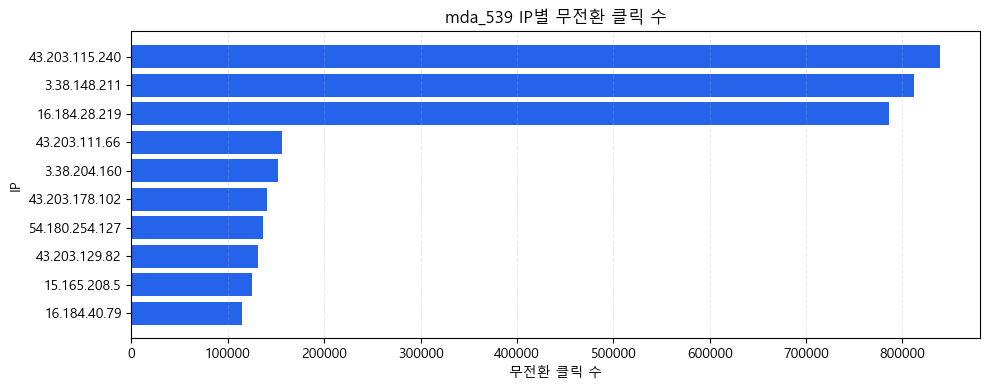

In [27]:
# 무전환 그래프
plot_ip = no_conv_top.sort_values('무전환클릭수')
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(plot_ip['user_ip'], plot_ip['무전환클릭수'], color='#2563eb')
ax.set_title(f'{label} IP별 무전환 클릭 수')
ax.set_xlabel('무전환 클릭 수')
ax.set_ylabel('IP')
ax.grid(axis='x', linestyle='--', alpha=0.25)
plt.tight_layout()
plt.show()


## 6. 매체 사례

클릭 증가 매체와 손실액 최대 매체 비교


손실액 최다 매체

- 손실액 최다 매체 mda_58
- 손실액 27,634,350원
- 전체 손실 점유율 55.2%
- 손실 발생 145,531건


In [28]:
# 손실 매체
loss_by_media = df_base.groupby('mda_idx', as_index=False).agg(
    손실액=('fraud_loss', 'sum'),
    전체건수=('click_key', 'count'),
    확정건수=('row_label', lambda x: (x == extreme_label).sum()),
)
loss_by_media = loss_by_media.sort_values('손실액', ascending=False).reset_index(drop=True)

# 최대 손실 선택
loss_mda = loss_by_media.loc[0, 'mda_idx']
loss_label = f'mda_{mda_key(loss_mda)}'
total_loss = df_base['fraud_loss'].sum()

# 손실 로그
loss_rows = df_base[df_base['mda_idx'].astype(str).eq(str(loss_mda))].copy()
loss_rows = loss_rows[loss_rows['fraud_loss'] > 0].copy()
loss = loss_rows['fraud_loss'].sum()


# 조건별 손실
cond_list = [
    ('CTIT 이상', 'ctit_error'),
    ('동일 IP 다기기', 'is_device_error'),
    ('IP 클릭 집중', 'is_click_error'),
]

# 조건 집계
cond_rows = []
for name, col in cond_list:
    rows_cond = loss_rows[loss_rows[col].fillna(False)]
    cond_rows.append({
        '조건': name,
        '발생건수': len(rows_cond),
        '손실액': rows_cond['fraud_loss'].sum(),
        '손실 비중(%)': rows_cond['fraud_loss'].sum() / loss * 100 if loss > 0 else 0,
    })
# 조건 표
cond = pd.DataFrame(cond_rows).sort_values('손실액', ascending=False)

display(cond)


,조건,발생건수,손실액,손실 비중(%)
1,동일 IP 다기기,145278,27591340,99.4389
2,IP 클릭 집중,141159,26739940,96.3704
0,CTIT 이상,23494,4037480,14.5510


In [29]:
# IP 손실
ip_loss = loss_rows.groupby('user_ip', as_index=False).agg(
    발생건수=('click_key', 'count'),
    손실액=('fraud_loss', 'sum'),
)
# IP 표
ip_loss['손실 비중(%)'] = ip_loss['손실액'] / ip_loss['손실액'].sum() * 100
ip_loss = ip_loss.sort_values('손실액', ascending=False).head(10).reset_index(drop=True)

display(ip_loss)


,user_ip,발생건수,손실액,손실 비중(%)
0,18.183.44.124,4960,943670,3.4010
1,13.158.73.27,4745,911720,3.2858
2,54.168.232.158,4873,906660,3.2676
3,54.168.100.207,4669,868480,3.1300
4,54.248.26.20,4559,839480,3.0255
5,52.195.213.206,3377,621360,2.2394
6,13.231.115.206,2686,512680,1.8477
7,13.158.81.129,2677,496630,1.7898
8,52.194.188.227,2519,464700,1.6748
9,13.115.172.63,2444,463240,1.6695


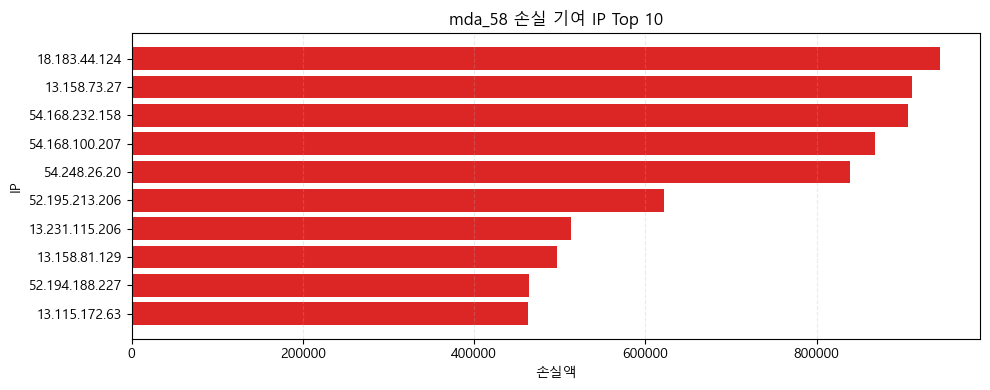

In [30]:
# 손실 그래프
fig, ax = plt.subplots(figsize=(10, 4))
chart = ip_loss.sort_values('손실액')
ax.barh(chart['user_ip'], chart['손실액'], color='#dc2626')
ax.set_title(f'{loss_label} 손실 기여 IP Top 10')
ax.set_xlabel('손실액')
ax.set_ylabel('IP')
ax.grid(axis='x', linestyle='--', alpha=0.25)
plt.tight_layout()
plt.show()


## 7. 대시보드 CSV

매체 요약, 일자 추이, 의심 로그 샘플 저장


In [31]:
# 매체 요약
media = df_base.groupby('mda_idx', as_index=False).agg(
    total_conv=('click_key', 'count'),
    extreme_cnt=('row_label', lambda x: (x == extreme_label).sum()),
    fraud_loss=('fraud_loss', 'sum'),
    avg_row_score=('row_score', 'mean'),
    adv_cost_sum=('adv_cost', 'sum'),
)

# 위험 라벨
media['extreme_ratio'] = media['extreme_cnt'] / media['total_conv']
media['Risk_Label'] = np.select(
    [
        media['extreme_ratio'] >= 0.70,
        media['extreme_ratio'] >= 0.40,
        media['extreme_ratio'] >= 0.20,
    ],
    [extreme_label, '위험', '주의'],
    default=normal_label,
)


In [32]:
# 일자 추이
daily = df_base.groupby(['click_date', 'mda_idx'], as_index=False).agg(
    total_conv=('click_key', 'count'),
    extreme_cnt=('row_label', lambda x: (x == extreme_label).sum()),
    fraud_loss=('fraud_loss', 'sum'),
)


In [33]:
# 의심 컬럼
suspect_cols = [
    'ads_idx', 'mda_idx', 'click_key', 'show_cost', 'adv_cost', 'rwd_cost', 'earn_cost',
    'click_date', 'ctit', 'ctit_error', 'ctit_label', 'user_ip', 'dvc_idx', 'device_count',
    'click_count', 'is_device_error', 'is_click_error', 'device_label', 'click_label',
    'is_rewarded', 'row_label', 'fraud_loss', 'row_score',
]

# 하위 점수 샘플
suspect = df_base.sort_values('row_score').groupby('mda_idx').head(100)[suspect_cols].copy()


In [ ]:
# CSV 저장
media.to_csv('C:/Users/ckcma/Downloads/temp2/04 ADS/data/dashboard_media_summary.csv', index=False, encoding='utf-8-sig')
daily.to_csv('C:/Users/ckcma/Downloads/temp2/04 ADS/data/dashboard_daily_trend.csv', index=False, encoding='utf-8-sig')
suspect.to_csv('C:/Users/ckcma/Downloads/temp2/04 ADS/data/dashboard_top_suspicious.csv', index=False, encoding='utf-8-sig')

# 저장 확인
pd.Series({
    'dashboard_media_summary': media.shape,
    'dashboard_daily_trend': daily.shape,
    'dashboard_top_suspicious': suspect.shape,
})


dashboard_media_summary        (174, 8)
dashboard_daily_trend         (3839, 5)
dashboard_top_suspicious    (14011, 23)
dtype: object

## 8. 분석용 CSV

확정 어뷰징 click_key 제거본 생성


In [35]:
# 제거 click_key
bad_reward_keys = set(df_base.loc[df_base['row_label'] == extreme_label, 'click_key'].dropna())

# 전체 참여 IP
ip_stat = df_engagement.groupby(['mda_idx', 'user_ip'], as_index=False).agg(
    device_count=('dvc_idx', 'nunique'),
    click_count=('click_key', 'count'),
)
# 0.1% 컷
device_cut_all = ip_stat['device_count'].quantile(0.999)
click_cut_all = ip_stat['click_count'].quantile(0.999)
# 제거 IP 조합
bad_pair = ip_stat[
    (ip_stat['device_count'] > device_cut_all) |
    (ip_stat['click_count'] > click_cut_all)
][['mda_idx', 'user_ip']]

# 참여 제거 키
bad_click = df_engagement[['click_key', 'mda_idx', 'user_ip']].merge(
    bad_pair, on=['mda_idx', 'user_ip'], how='inner'
)
bad_click_keys = set(bad_click['click_key'].dropna())


In [ ]:
# 적립 제거본
reward_clean_path = 'C:/Users/ckcma/Downloads/temp2/04 ADS/data/cleaned_reward_data.csv'
# 적립 카운트
reward_total_rows = 0
reward_clean_rows = 0
first = True
for part in pd.read_csv('C:/Users/ckcma/Downloads/temp2/IVE_광고적립_all.csv', chunksize=500_000, encoding='utf-8-sig'):
    reward_total_rows += len(part)
    part = part.loc[~part['click_key'].isin(bad_reward_keys)].copy()
    reward_clean_rows += len(part)
    part.to_csv(reward_clean_path, index=False, encoding='utf-8-sig', mode='w' if first else 'a', header=first)
    first = False


In [ ]:
# 참여 제거본
click_clean_path = 'C:/Users/ckcma/Downloads/temp2/04 ADS/data/cleaned_engagement_data.csv'
# 참여 카운트
click_total_rows = 0
click_clean_rows = 0
first = True
carrier_removed = False
for part in pd.read_csv('C:/Users/ckcma/Downloads/temp2/IVE_광고참여정보.csv', chunksize=1_000_000, encoding='utf-8-sig'):
    click_total_rows += len(part)
    part = part.loc[~part['click_key'].isin(bad_click_keys)].copy()
    if 'carrier' in part.columns:
        part = part.drop(columns=['carrier'])
        carrier_removed = True
    click_clean_rows += len(part)
    part.to_csv(click_clean_path, index=False, encoding='utf-8-sig', mode='w' if first else 'a', header=first)
    first = False


In [38]:
# 제거 규모
reward_drop = reward_total_rows - reward_clean_rows
click_drop = click_total_rows - click_clean_rows
reward_drop_rate = reward_drop / reward_total_rows * 100 if reward_total_rows else 0
click_drop_rate = click_drop / click_total_rows * 100 if click_total_rows else 0

# 제거 확인
pd.Series({
    '적립 제거 키': len(bad_reward_keys),
    '참여 제거 키': len(bad_click_keys),
    '적립 원본 행': reward_total_rows,
    '적립 제거 후': reward_clean_rows,
    '적립 제거 행': reward_drop,
    '적립 제거율(%)': round(reward_drop_rate, 4),
    '참여 원본 행': click_total_rows,
    '참여 제거 후': click_clean_rows,
    '참여 제거 행': click_drop,
    '참여 제거율(%)': round(click_drop_rate, 4),
    'carrier 제거': carrier_removed,
})


적립 제거 키         540743
참여 제거 키        6352324
적립 원본 행        1475031
적립 제거 후         934288
적립 제거 행         540743
적립 제거율(%)      36.6598
참여 원본 행       16854865
참여 제거 후       10502541
참여 제거 행        6352324
참여 제거율(%)      37.6884
carrier 제거        True
dtype: object

## 9. 산출물 확인

CSV 저장 여부와 컬럼만 확인


In [ ]:
files = [
    'dashboard_media_summary.csv',
    'dashboard_daily_trend.csv',
    'dashboard_top_suspicious.csv',
    'cleaned_reward_data.csv',
    'cleaned_engagement_data.csv',
]

# 컬럼 확인
file_check = []
for name in files:
    sample = pd.read_csv('C:/Users/ckcma/Downloads/temp2/04 ADS/data/' + name, nrows=1, encoding='utf-8-sig')
    assert 'is_mda539' not in sample.columns
    file_check.append({'file': name, 'cols': len(sample.columns)})

pd.DataFrame(file_check)


,file,cols
0,dashboard_media_summary.csv,8
1,dashboard_daily_trend.csv,5
2,dashboard_top_suspicious.csv,23
3,cleaned_reward_data.csv,15
4,cleaned_engagement_data.csv,16
